<a href="https://colab.research.google.com/github/jamoffl3/24ADI006-DEEP-LEARNING/blob/main/Perceptron_W.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Single Layer Perceptron**

AND GATE IMPLEMENTATION

Input       Expected    Predicted   
[0, 0]      0           0           
[0, 1]      0           0           
[1, 0]      0           0           
[1, 1]      1           1           

AND Gate Accuracy: 100.00%


OR GATE IMPLEMENTATION

Input       Expected    Predicted   
[0, 0]      0           0           
[0, 1]      1           1           
[1, 0]      1           1           
[1, 1]      1           1           

OR Gate Accuracy: 100.00%


RANDOM DATASET CLASSIFICATION

Testing Accuracy: 100.00%


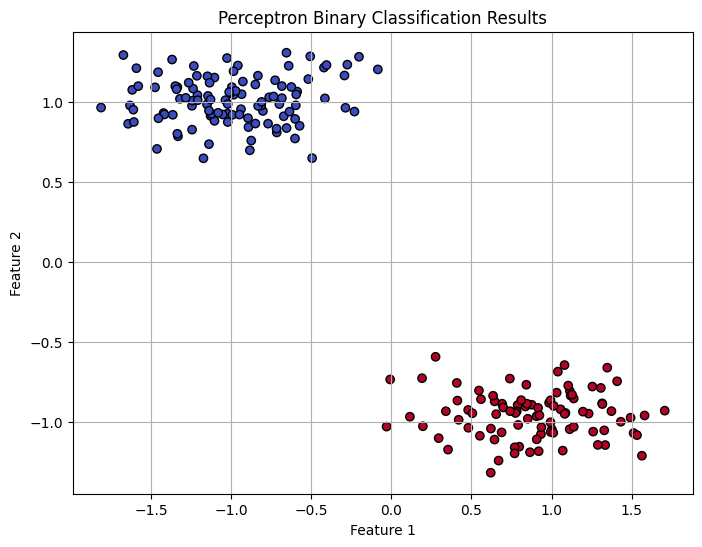

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


class Perceptron:

    def __init__(self, n_features, learning_rate=0.1):
        self.learning_rate = learning_rate
        self.weights = np.zeros(n_features)
        self.bias = 0

    def activation(self, value):
        if value >= 0:
            return 1
        return 0

    def predict(self, X):

        if X.ndim == 1:
            linear_output = np.dot(X, self.weights) + self.bias
            return self.activation(linear_output)

        predictions = []

        for sample in X:
            linear_output = np.dot(sample, self.weights) + self.bias
            predictions.append(self.activation(linear_output))

        return np.array(predictions)

    def fit(self, X, y, epochs=20):

        for _ in range(epochs):

            for sample, target in zip(X, y):

                prediction = self.predict(sample)

                error = target - prediction

                self.weights += self.learning_rate * error * sample
                self.bias += self.learning_rate * error


# ==================================================
# TASK 1 - AND GATE
# ==================================================

print("=" * 50)
print("AND GATE IMPLEMENTATION")
print("=" * 50)

X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_and = np.array([0, 0, 0, 1])

and_model = Perceptron(2, learning_rate=0.1)

and_model.fit(X_and, y_and, epochs=20)

and_predictions = and_model.predict(X_and)

print("\n{:<12}{:<12}{:<12}".format("Input", "Expected", "Predicted"))

for x, actual, pred in zip(X_and, y_and, and_predictions):
    print("{:<12}{:<12}{:<12}".format(
        f"[{int(x[0])}, {int(x[1])}]",
        int(actual),
        int(pred)
    ))

and_accuracy = np.mean(and_predictions == y_and)

print("\nAND Gate Accuracy: {:.2f}%".format(and_accuracy * 100))


# ==================================================
# TASK 1 - OR GATE
# ==================================================

print("\n")
print("=" * 50)
print("OR GATE IMPLEMENTATION")
print("=" * 50)

X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_or = np.array([0, 1, 1, 1])

or_model = Perceptron(2, learning_rate=0.1)

or_model.fit(X_or, y_or, epochs=20)

or_predictions = or_model.predict(X_or)

print("\n{:<12}{:<12}{:<12}".format("Input", "Expected", "Predicted"))

for x, actual, pred in zip(X_or, y_or, or_predictions):
    print("{:<12}{:<12}{:<12}".format(
        f"[{int(x[0])}, {int(x[1])}]",
        int(actual),
        int(pred)
    ))

or_accuracy = np.mean(or_predictions == y_or)

print("\nOR Gate Accuracy: {:.2f}%".format(or_accuracy * 100))


# ==================================================
# TASK 2 - RANDOM DATASET
# ==================================================

print("\n")
print("=" * 50)
print("RANDOM DATASET CLASSIFICATION")
print("=" * 50)

X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=2,
    cluster_std=1,
    random_state=23
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Perceptron(2, learning_rate=0.1)

model.fit(X_train, y_train, epochs=100)

predictions = model.predict(X_test)

accuracy = np.mean(predictions == y_test)

print("\nTesting Accuracy: {:.2f}%".format(accuracy * 100))

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=predictions,
    cmap="coolwarm",
    edgecolors="black"
)

plt.title("Perceptron Binary Classification Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)

plt.show()

**Single Layer MNIST**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)


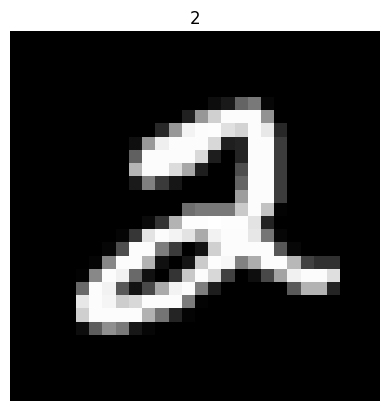

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8790 - loss: 0.4669
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9156 - loss: 0.3028
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9211 - loss: 0.2830
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9238 - loss: 0.2731
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9260 - loss: 0.2667
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9268 - loss: 0.2676
Loss: 0.2676074802875519
Accuracy: 0.926800012588501


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(x_train.shape)

plt.imshow(x_train[5], cmap="gray")
plt.title(y_train[5])
plt.axis("off")
plt.show()

x_train = x_train.astype("float32")/255
x_test = x_test.astype("float32")/255

x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

model = tf.keras.Sequential()

model.add(tf.keras.layers.Dense(
    units=10,
    activation="sigmoid",
    input_shape=(784,)
))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    x_train,
    y_train,
    epochs=5,
    verbose=1
)

loss, accuracy = model.evaluate(x_test,y_test)

print("Loss:",loss)
print("Accuracy:",accuracy)

**Multi Layer Perceptron**

(60000, 28, 28)
(60000,)


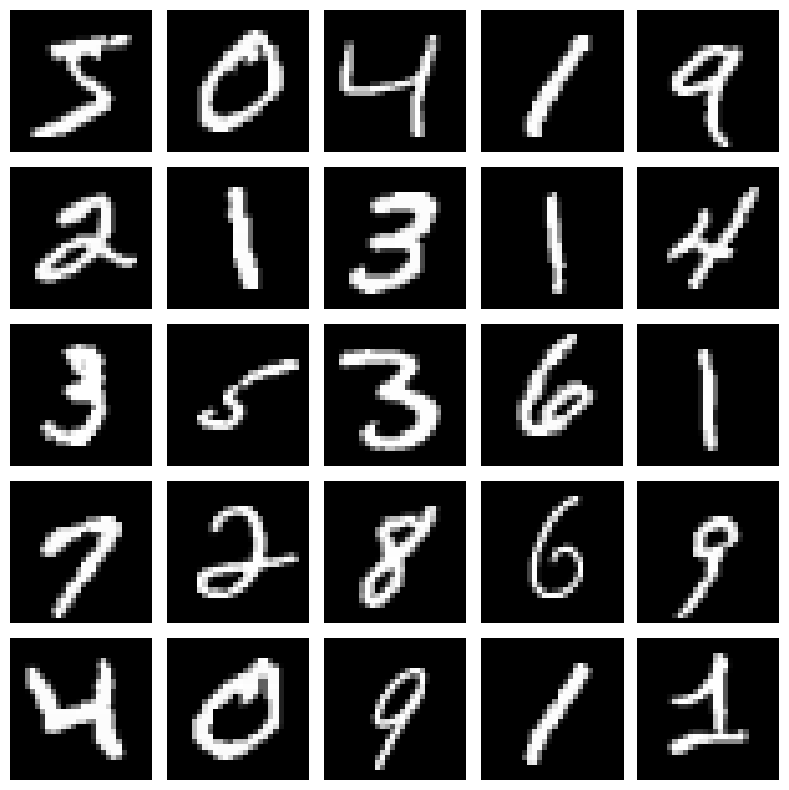

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7397 - loss: 0.9657 - val_accuracy: 0.9015 - val_loss: 0.3478
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9134 - loss: 0.3077 - val_accuracy: 0.9326 - val_loss: 0.2448
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9350 - loss: 0.2324 - val_accuracy: 0.9452 - val_loss: 0.1992
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9469 - loss: 0.1885 - val_accuracy: 0.9536 - val_loss: 0.1720
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9550 - loss: 0.1602 - val_accuracy: 0.9559 - val_loss: 0.1548
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9611 - loss: 0.1400 - val_accuracy: 0.9588 - val_loss: 0.1449
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9655 - loss: 0.1233 - val_accuracy: 0.9612 - val_loss: 0.1314
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9694 - loss: 0.1085 - val_accuracy: 0.9626 - v

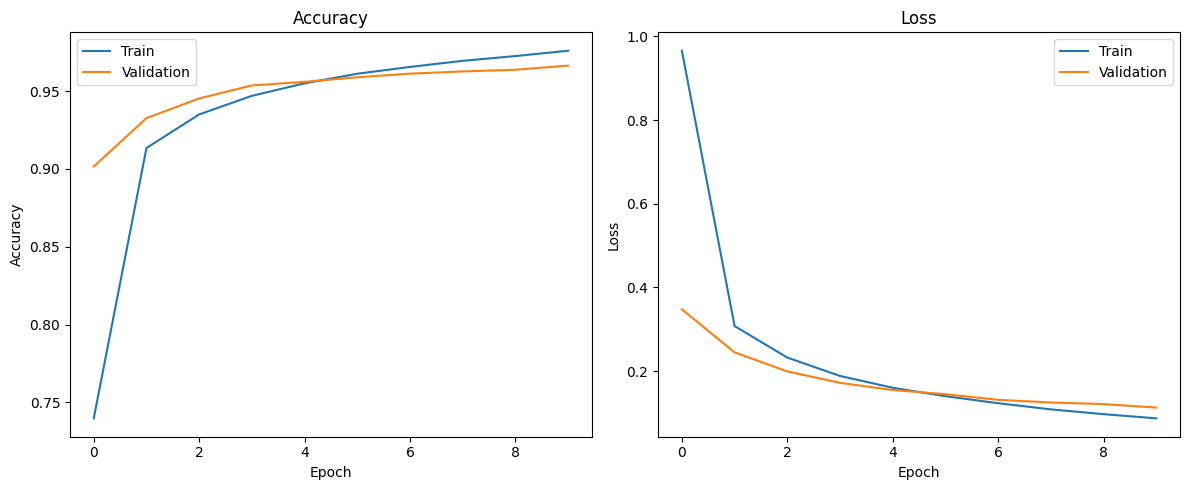

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

print(x_train.shape)
print(y_train.shape)

plt.figure(figsize=(8,8))

for i in range(25):

    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i],cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

model=tf.keras.Sequential()

model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(128,activation="relu"))
model.add(tf.keras.layers.Dense(64,activation="relu"))
model.add(tf.keras.layers.Dense(10,activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history=model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=1024,
    validation_split=0.2
)

score=model.evaluate(x_test,y_test,verbose=0)

print("Test Loss:",score[0])
print("Test Accuracy:",score[1])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.tight_layout()
plt.show()